# AlphaStock: Investment Strategy using Deep Reinforcement Attention Networks

**IE 620 Project, Dhairya Kantawala, IIT Bombay**

This notebook implements the AlphaStock paper with a key extension: replacing the LSTM encoder with a **2-layer MLP encoder** to reduce overfitting risk and parameter count.

**Paper objective:** Maximize the Sharpe ratio of a long-short portfolio using a policy gradient (REINFORCE) approach with cross-stock attention.

## 1. Imports & Seed

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Data Loading

We use `helper_functions.py` which provides:
- `months`: list of trading months
- `features`: list of feature names
- `get_state_reward(i)`: returns `(state_i, reward_i)` for month `i`

Each `state_i` is a list of feature vectors (one per stock), and `reward_i` is a list of next-period returns (one per stock).

In [1]:
from helper_functions import *

print(f"Total months: {len(months)}")
print(f"Number of features: {len(features)}")
print(f"Features: {features}")

Total months: 311
Number of features: 14
Features: ['ret_1m', 'ret_3m', 'mom_12m', 'vol_3m', 'vol_6m', 'vol_z', 'vol_trend', 'ey_z', 'bm_z', 'mc_z', 'rev_6m', 'mom_vol_adj', 'value_mom', 'liquidity_adj_mom']


## 3. Precompute States & Rewards

We precompute all states and rewards upfront to avoid recomputing during training.

In [3]:
set_seed(42)

states = []
rewards = []
for i in tqdm(range(len(months)), desc="Loading data"):
    state_i, reward_i = get_state_reward(i)
    states.append(state_i)
    rewards.append(reward_i)

print(f"\nNumber of months loaded: {len(states)}")
print(f"Stocks in first month: {len(states[0])}")
print(f"Feature dim per stock: {len(states[0][0]) if hasattr(states[0][0], '__len__') else 'scalar'}")

Loading data: 100%|███████████████████████████████████████████████████████████████████| 311/311 [02:17<00:00,  2.27it/s]


Number of months loaded: 311
Stocks in first month: 11
Feature dim per stock: 14


## 4. Model Architecture

### 4.1 MLP Encoder (replaces LSTM)

The original paper uses an LSTM with history attention to encode each stock's time-series features into a representation vector $r^{(i)}$. 

Our extension replaces this with a **2-layer MLP**:
$$r^{(i)} = \text{MLP}(x^{(i)}_t)$$

Rationale:
- Fewer parameters → less overfitting on limited financial data
- The features from `helper_functions` are already pre-computed summaries (not raw time-series), so sequential modeling may be unnecessary
- BatchNorm + Dropout provide regularization

In [4]:
class MLPEncoder(nn.Module):
    """
    2-Layer MLP Encoder: maps per-stock feature vector to a latent representation.
    
    Paper equivalent: LSTM encoder + history attention → r^(i)
    Our extension: MLP with BatchNorm and Dropout → r^(i)
    
    Architecture:
        input_dim → hidden_dim → hidden_dim → output_dim (d_model)
    """
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

### 4.2 Cross-Stock Attention

This is the core innovation of AlphaStock. It models **inter-stock relationships** using scaled dot-product attention:

$$\alpha_{ij} = \frac{\exp(q^{(i)\top} k^{(j)} / \sqrt{d_k})}{\sum_{j'} \exp(q^{(i)\top} k^{(j')} / \sqrt{d_k})}$$

$$a^{(i)} = \sum_j \alpha_{ij} v^{(j)}$$

The winner score $s^{(i)} = w_s^\top a^{(i)}$ determines which stocks are ranked higher (for longing) or lower (for shorting).

In [5]:
class CrossStockAttention(nn.Module):
    """
    Cross-Asset Attention mechanism from the AlphaStock paper.
    
    Given stock representations r = (r^(1), ..., r^(N)):
    1. Project to Q, K, V
    2. Compute scaled dot-product attention across stocks
    3. Output a scalar 'winner score' s^(i) per stock
    
    The score captures how each stock relates to all others,
    enabling the model to learn relative rankings.
    """
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.WQ = nn.Linear(d_model, d_model)
        self.WK = nn.Linear(d_model, d_model)
        self.WV = nn.Linear(d_model, d_model)
        
        self.ws = nn.Linear(d_model, 1)

    def forward(self, r):
        Q = self.WQ(r)
        K = self.WK(r)
        V = self.WV(r)

        scores = torch.matmul(Q, K.T) / math.sqrt(self.d_model)
        alpha = F.softmax(scores, dim=1)

        A = torch.matmul(alpha, V)

        s = self.ws(A).squeeze(-1)

        return s

### 4.3 Portfolio Construction

The paper constructs a **zero-investment (long-short) portfolio**:
- Top-scored stocks get positive (long) weights
- Bottom-scored stocks get negative (short) weights
- Weights sum to zero: $\sum_i b^{+(i)} = 1$, $\sum_i b^{-(i)} = 1$

We use a **soft differentiable** version:
$$b^{+(i)} = \text{softmax}(s)_i, \quad b^{-(i)} = \text{softmax}(-s)_i$$
$$b_i = b^{+(i)} - b^{-(i)}, \quad \text{normalized so } \sum |b_i| = 1$$

This avoids the non-differentiable top-G / bottom-G selection in the paper.

In [6]:
def construct_portfolio_soft(s):
    """
    Differentiable portfolio construction.
    
    Args:
        s: (N,) winner scores from attention
    
    Returns:
        b: (N,) portfolio weights, approximately zero-sum,
           normalized so |b|_1 ≈ 1
    
    High s → long, Low s → short
    """
    long_weights  = torch.softmax(s, dim=0)
    short_weights = torch.softmax(-s, dim=0)
    b = long_weights - short_weights
    b = b / (b.abs().sum() + 1e-8)
    return b

### 4.4 Full Trading Model

In [7]:
class TradingModel(nn.Module):
    """
    Complete AlphaStock model (MLP variant).
    
    Pipeline: X_t^(i) → MLP → r^(i) → CrossStockAttention → s^(i) → portfolio b_t
    
    This is a deterministic policy: a_t = μ_θ(s_t)
    The policy directly outputs portfolio weights.
    
    Args:
        input_dim: number of features per stock
        hidden_dim: MLP hidden layer size
        d_model: attention/representation dimension
    """
    def __init__(self, input_dim, hidden_dim=32, d_model=16):
        super().__init__()
        self.encoder = MLPEncoder(input_dim, hidden_dim, d_model)
        self.attention = CrossStockAttention(d_model)

    def forward(self, state_i, reward_i):
        """
        Forward pass for one time step.
        
        Args:
            state_i: list of N feature vectors (one per stock)
            reward_i: list of N next-period returns
        
        Returns:
            r: (N, d_model) stock representations
            s: (N,) winner scores
            b: (N,) portfolio weights
            R_t: scalar portfolio return for this period
        """
        x = torch.tensor(
            [s.to_numpy() if hasattr(s, "to_numpy") else s for s in state_i],
            dtype=torch.float32
        )
        returns = torch.tensor(reward_i, dtype=torch.float32)

        r = self.encoder(x) 
        
        s = self.attention(r) 
        
        b = construct_portfolio_soft(s)
        
        R_t = torch.sum(b * returns)
        
        return r, s, b, R_t

## 5. Loss Function: Sharpe Ratio Objective

The paper's objective is to maximize:
$$J(\theta) = \frac{\mu(\theta)}{\sigma(\theta)}$$

We implement this as a loss to minimize. Following the paper, we also add:
- A **drawdown penalty** to discourage large peak-to-trough drops
- Weighting between Sharpe and mean return for training stability

In [8]:
def compute_loss(R_list, H0=0.0):
    """
    Compute training loss based on the Sharpe ratio objective.
    
    The paper maximizes J(θ) = μ/σ (Sharpe ratio).
    We minimize: loss = -λ₁·Sharpe - λ₂·mean_return + λ₃·max_drawdown
    
    The H0 parameter is the market-beating threshold (baseline).
    When H0 > 0, the model is pushed to beat the market's Sharpe ratio.
    
    Args:
        R_list: list of T portfolio returns [R_1, ..., R_T]
        H0: market Sharpe ratio baseline (default 0.0)
    
    Returns:
        loss: scalar loss to minimize
    """
    R = torch.stack(R_list)
    mu = R.mean()
    sigma = R.std() + 1e-6
    
    sharpe = mu / sigma
    
    mean_return = mu
    
    cumulative = torch.cumprod(1 + R, dim=0)
    peak = torch.cummax(cumulative, dim=0).values
    drawdown = ((peak - cumulative) / (peak + 1e-8)).max()
    
    loss = -0.5 * (sharpe - H0) - 0.5 * mean_return * 12 + 0.2 * drawdown
    
    return loss

## 6. Training Loop

Training procedure following the paper's algorithm:
1. For each epoch, slide a window of `T` months across the training data
2. In each window, collect portfolio returns $R_1, ..., R_T$
3. Compute the Sharpe-based loss over the window
4. Backpropagate and update $\theta$

Key hyperparameters:
- `window = 12`: trajectory length (12 months = 1 year)
- `holdout = 24`: last 24 months reserved for testing
- Cosine annealing LR schedule for stable convergence

In [9]:
def train(model, optimizer, scheduler, all_states, all_rewards, 
         epochs=50, window=12, holdout=24, H0=0.0, verbose=True):
    """
    Train the AlphaStock model.
    
    Uses a sliding window approach over the training data.
    Each window is treated as a trajectory for the REINFORCE-style update.
    
    Args:
        model: TradingModel instance
        optimizer: torch optimizer
        scheduler: LR scheduler
        all_states: precomputed states for all months
        all_rewards: precomputed rewards for all months
        epochs: number of training epochs
        window: trajectory length in months
        holdout: number of months to hold out for testing
        H0: market Sharpe baseline
        verbose: print progress
    
    Returns:
        history: dict of training metrics per epoch
    """
    T = len(all_states) - holdout
    
    history = {
        'epoch': [], 'sharpe': [], 'avg_return': [], 'lr': []
    }
    
    for epoch in range(epochs):
        model.train()
        sharpe_list, return_list = [], []

        for start in range(T - window):
            optimizer.zero_grad()

            R_list = []
            for t in range(start, start + window):
                _, _, _, R_t = model(all_states[t], all_rewards[t])
                R_list.append(R_t)

            loss = compute_loss(R_list, H0=H0)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            R = torch.stack(R_list)
            sharpe_list.append((R.mean() / (R.std() + 1e-6)).item())
            return_list.append(R.sum().item())

        scheduler.step()
        
        avg_sharpe = sum(sharpe_list) / len(sharpe_list)
        avg_return = sum(return_list) / len(return_list)
        lr = scheduler.get_last_lr()[0]
        
        history['epoch'].append(epoch)
        history['sharpe'].append(avg_sharpe)
        history['avg_return'].append(avg_return)
        history['lr'].append(lr)

        if verbose:
            print(f"Epoch {epoch:03d} | Sharpe: {avg_sharpe:.4f} | "
                  f"Avg Return: {avg_return:.4f} | LR: {lr:.6f}")
    
    return history

## 7. Run Training

In [17]:
set_seed(42)

input_dim = len(features)
model = TradingModel(input_dim, hidden_dim=32, d_model=16)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Input dimension: {input_dim}")
print()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

history = train(model, optimizer, scheduler, states, rewards, epochs=100)

Total parameters: 3,025
Trainable parameters: 3,025
Input dimension: 14

Epoch 000 | Sharpe: 0.4814 | Avg Return: 0.0792 | LR: 0.000999
Epoch 001 | Sharpe: 0.5757 | Avg Return: 0.1077 | LR: 0.000996
Epoch 002 | Sharpe: 0.6430 | Avg Return: 0.1153 | LR: 0.000991
Epoch 003 | Sharpe: 0.6476 | Avg Return: 0.1152 | LR: 0.000984
Epoch 004 | Sharpe: 0.7584 | Avg Return: 0.1384 | LR: 0.000976
Epoch 005 | Sharpe: 0.7894 | Avg Return: 0.1245 | LR: 0.000965
Epoch 006 | Sharpe: 0.8285 | Avg Return: 0.1371 | LR: 0.000953
Epoch 007 | Sharpe: 0.9192 | Avg Return: 0.1482 | LR: 0.000939
Epoch 008 | Sharpe: 0.8760 | Avg Return: 0.1384 | LR: 0.000923
Epoch 009 | Sharpe: 0.9555 | Avg Return: 0.1494 | LR: 0.000905
Epoch 010 | Sharpe: 0.9938 | Avg Return: 0.1499 | LR: 0.000886
Epoch 011 | Sharpe: 1.0688 | Avg Return: 0.1578 | LR: 0.000866
Epoch 012 | Sharpe: 1.0349 | Avg Return: 0.1572 | LR: 0.000844
Epoch 013 | Sharpe: 1.1389 | Avg Return: 0.1643 | LR: 0.000821
Epoch 014 | Sharpe: 1.1277 | Avg Return: 0.16

## 8. Training Curves

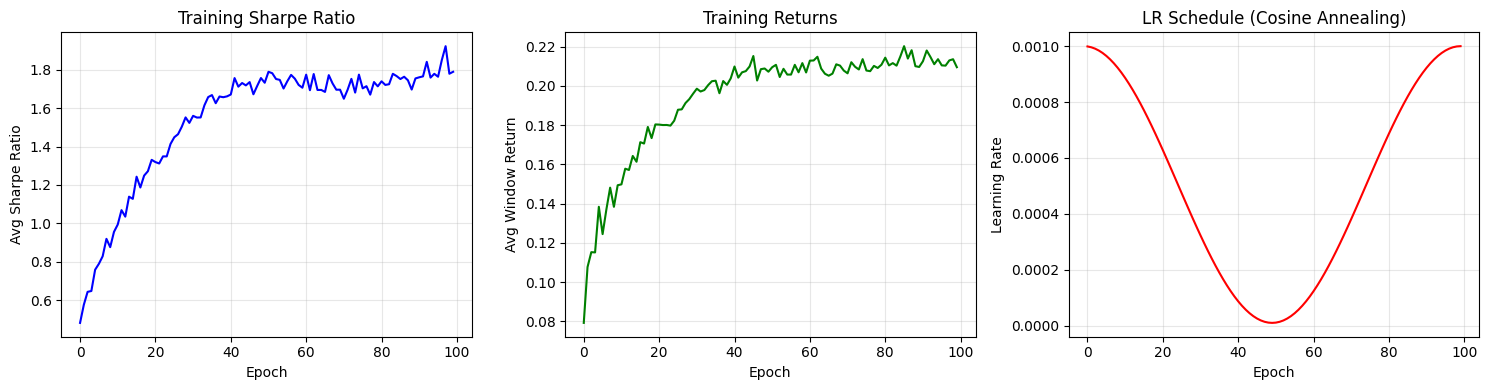

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['epoch'], history['sharpe'], 'b-', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Avg Sharpe Ratio')
axes[0].set_title('Training Sharpe Ratio')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], history['avg_return'], 'g-', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Avg Window Return')
axes[1].set_title('Training Returns')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['epoch'], history['lr'], 'r-', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule (Cosine Annealing)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation on Test Set

We evaluate on the **last 24 months** (held out during training).

Metrics:
- **Sharpe Ratio**: risk-adjusted return (higher = better)
- **Total Return**: cumulative return over test period
- **Final Equity**: value of \$1 invested at the start
- **Maximum Drawdown**: worst peak-to-trough decline
- **Annualized Return**: geometric mean annualized
- **Annualized Volatility**: standard deviation × √12

In [19]:
def evaluate(model, test_states, test_rewards, period_label="Test"):
    """
    Evaluate the model on a set of states/rewards.
    
    Args:
        model: trained TradingModel
        test_states: list of state data for test months
        test_rewards: list of reward data for test months
        period_label: label for printing
    
    Returns:
        R: tensor of period returns
        metrics: dict of performance metrics
    """
    model.eval()
    
    R_list = []
    all_weights = []
    
    with torch.no_grad():
        for t in range(len(test_states)):
            _, s, b, R_t = model(test_states[t], test_rewards[t])
            R_list.append(R_t)
            all_weights.append(b.numpy())

    R = torch.stack(R_list)
    
    mu = R.mean().item()
    sigma = R.std().item()
    sharpe = mu / (sigma + 1e-8)
    total_return = R.sum().item()
    
    equity = torch.cumprod(1 + R, dim=0)
    final_equity = equity[-1].item()
    
    peak = torch.cummax(equity, dim=0).values
    drawdown = ((peak - equity) / (peak + 1e-8))
    max_drawdown = drawdown.max().item()
    
    n_months = len(R_list)
    annualized_return = (final_equity ** (12.0 / n_months) - 1)
    annualized_vol = sigma * math.sqrt(12)
    annualized_sharpe = sharpe * math.sqrt(12)
    
    metrics = {
        'sharpe': sharpe,
        'annualized_sharpe': annualized_sharpe,
        'total_return': total_return,
        'final_equity': final_equity,
        'annualized_return': annualized_return,
        'annualized_vol': annualized_vol,
        'max_drawdown': max_drawdown,
        'monthly_mean': mu,
        'monthly_std': sigma,
    }
    
    print(f"\n{'='*50}")
    print(f"  {period_label} Performance ({n_months} months)")
    print(f"{'='*50}")
    print(f"  Monthly Sharpe:       {sharpe:.4f}")
    print(f"  Annualized Sharpe:    {annualized_sharpe:.4f}")
    print(f"  Total Return:         {total_return:.4f} ({total_return*100:.2f}%)")
    print(f"  Final Equity (\$1):    {final_equity:.4f}")
    print(f"  Annualized Return:    {annualized_return*100:.2f}%")
    print(f"  Annualized Volatility:{annualized_vol*100:.2f}%")
    print(f"  Max Drawdown:         {max_drawdown*100:.2f}%")
    print(f"{'='*50}")
    
    return R, metrics, all_weights

<>:67: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:67: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/wl/q8prsl_x2_g_hl0vv6cf0xj00000gn/T/ipykernel_37340/3299642224.py:67: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  print(f"  Final Equity (\$1):    {final_equity:.4f}")


In [20]:
test_states_24 = states[-24:]
test_rewards_24 = rewards[-24:]

R_24, metrics_24, weights_24 = evaluate(model, test_states_24, test_rewards_24, 
                                         period_label="Test (24 months)")

test_states_12 = states[-12:]
test_rewards_12 = rewards[-12:]

R_12, metrics_12, weights_12 = evaluate(model, test_states_12, test_rewards_12, 
                                         period_label="Test (12 months)")


  Test (24 months) Performance (24 months)
  Monthly Sharpe:       0.1863
  Annualized Sharpe:    0.6454
  Total Return:         0.0311 (3.11%)
  Final Equity (\$1):    1.0310
  Annualized Return:    1.54%
  Annualized Volatility:2.41%
  Max Drawdown:         2.65%

  Test (12 months) Performance (12 months)
  Monthly Sharpe:       0.0327
  Annualized Sharpe:    0.1134
  Total Return:         0.0027 (0.27%)
  Final Equity (\$1):    1.0025
  Annualized Return:    0.25%
  Annualized Volatility:2.41%
  Max Drawdown:         2.65%


## 10. Equity Curve & Drawdown Visualization

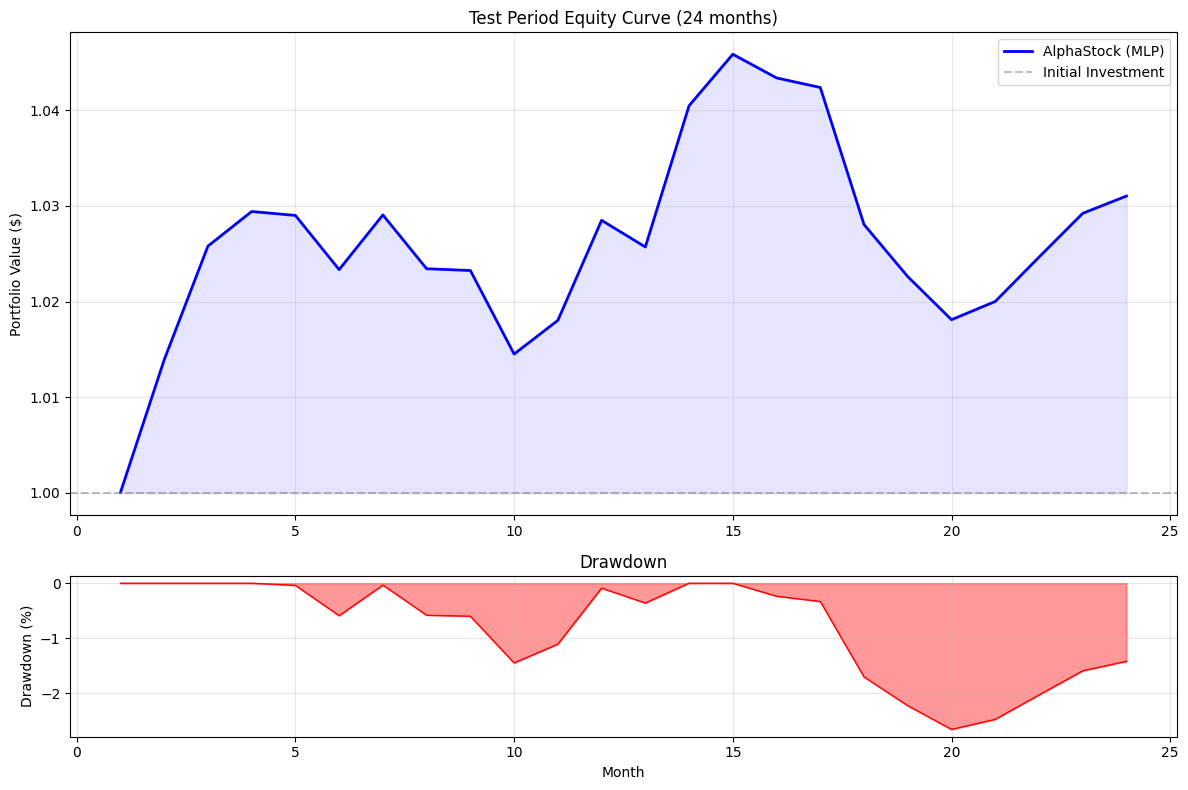

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

equity_24 = torch.cumprod(1 + R_24, dim=0).numpy()
months_axis = np.arange(1, len(equity_24) + 1)

axes[0].plot(months_axis, equity_24, 'b-', linewidth=2, label='AlphaStock (MLP)')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Initial Investment')
axes[0].fill_between(months_axis, 1.0, equity_24, alpha=0.1, color='blue')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title('Test Period Equity Curve (24 months)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

equity_tensor = torch.cumprod(1 + R_24, dim=0)
peak = torch.cummax(equity_tensor, dim=0).values
dd = ((peak - equity_tensor) / (peak + 1e-8)).numpy()

axes[1].fill_between(months_axis, 0, -dd * 100, color='red', alpha=0.4)
axes[1].plot(months_axis, -dd * 100, 'r-', linewidth=1)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Monthly Returns Distribution

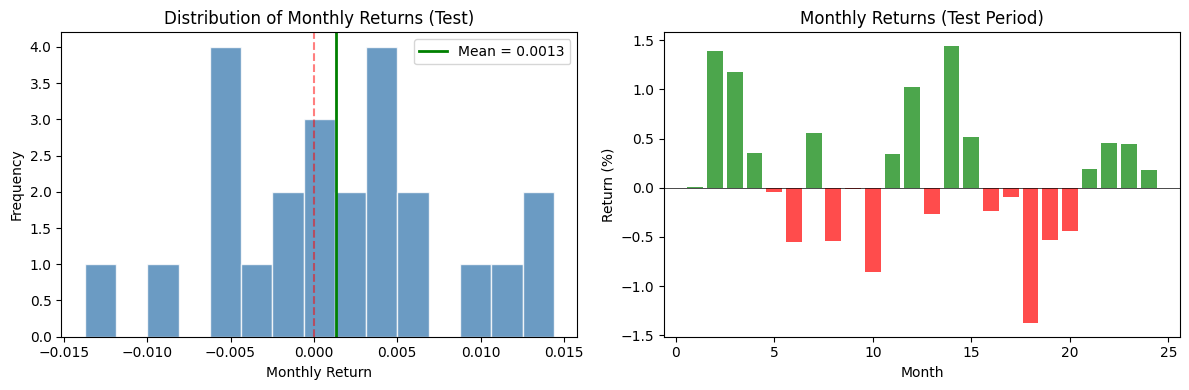

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

returns_np = R_24.detach().numpy()

axes[0].hist(returns_np, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=returns_np.mean(), color='green', linestyle='-', linewidth=2, 
                label=f'Mean = {returns_np.mean():.4f}')
axes[0].set_xlabel('Monthly Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Monthly Returns (Test)')
axes[0].legend()

colors = ['green' if r > 0 else 'red' for r in returns_np]
axes[1].bar(range(1, len(returns_np)+1), returns_np * 100, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Return (%)')
axes[1].set_title('Monthly Returns (Test Period)')

plt.tight_layout()
plt.savefig('returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
train_end = len(states) - 24
train_states = states[train_end-24:train_end]
train_rewards = rewards[train_end-24:train_end]

R_train, metrics_train, _ = evaluate(model, train_states, train_rewards,
                                      period_label="Train (last 24 months)")

print("\n" + "="*60)
print("  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("="*60)
print(f"{'Metric':<25} {'Train':>12} {'Test':>12}")
print("-"*60)
for key in ['annualized_sharpe', 'annualized_return', 'annualized_vol', 'max_drawdown']:
    label = key.replace('_', ' ').title()
    train_val = metrics_train[key]
    test_val = metrics_24[key]
    if 'return' in key or 'vol' in key or 'drawdown' in key:
        print(f"{label:<25} {train_val*100:>11.2f}% {test_val*100:>11.2f}%")
    else:
        print(f"{label:<25} {train_val:>12.4f} {test_val:>12.4f}")
print("="*60)


  Train (last 24 months) Performance (24 months)
  Monthly Sharpe:       0.7530
  Annualized Sharpe:    2.6085
  Total Return:         0.1110 (11.10%)
  Final Equity (\$1):    1.1166
  Annualized Return:    5.67%
  Annualized Volatility:2.13%
  Max Drawdown:         0.81%

  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON
Metric                           Train         Test
------------------------------------------------------------
Annualized Sharpe               2.6085       0.6454
Annualized Return                5.67%        1.54%
Annualized Vol                   2.13%        2.41%
Max Drawdown                     0.81%        2.65%


## 12. Gradient Analysis of Sharpe Objective

As derived in the paper, the gradient of the Sharpe ratio decomposes as:
$$\nabla_\theta J(\theta) = \sum_t w_t \nabla_\theta R_t$$
where $w_t = \frac{1}{T\sigma} - \frac{\mu}{T\sigma^3}(R_t - \mu)$

This means timesteps with returns far from the mean get **downweighted** — the model is rewarded for **consistency**, not just high returns.

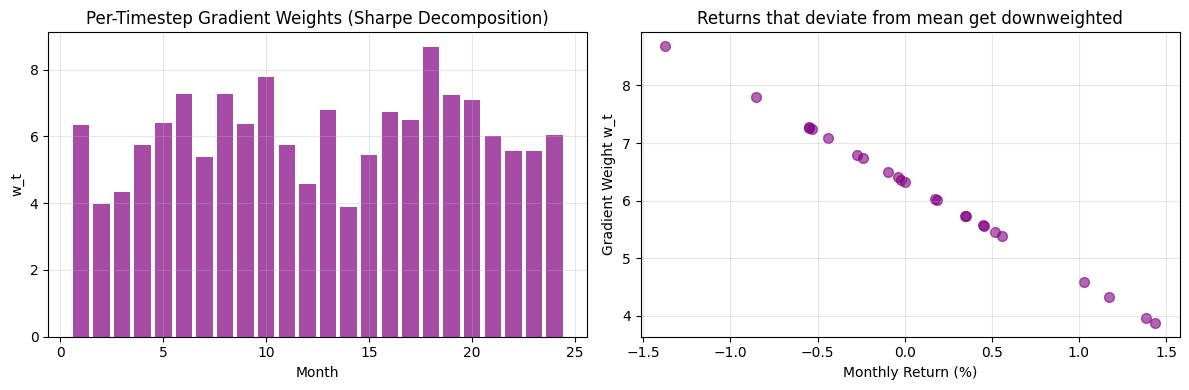

In [25]:
R_np = R_24.detach().numpy()
mu_val = R_np.mean()
sigma_val = R_np.std() + 1e-6
T_val = len(R_np)

w_t = 1.0 / (T_val * sigma_val) - mu_val / (T_val * sigma_val**3) * (R_np - mu_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, T_val+1), w_t, color='purple', alpha=0.7)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('w_t')
axes[0].set_title('Per-Timestep Gradient Weights (Sharpe Decomposition)')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Scatter: return vs weight
axes[1].scatter(R_np * 100, w_t, c='purple', alpha=0.6, s=50)
axes[1].set_xlabel('Monthly Return (%)')
axes[1].set_ylabel('Gradient Weight w_t')
axes[1].set_title('Returns that deviate from mean get downweighted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sharpe_gradient_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary

**What we implemented:**
1. AlphaStock paper's core architecture with MLP encoder (instead of LSTM)
2. Cross-stock attention mechanism for modeling inter-stock relationships
3. Differentiable long-short portfolio construction
4. Sharpe ratio maximization objective with drawdown penalty
5. REINFORCE-style policy gradient training with sliding windows

**Key extension:** Replaced LSTM with 2-layer MLP encoder to reduce parameter count and overfitting risk on limited financial data.